In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def run_spatiotemporal_etas(T_end, x_range, y_range, params, dt=0.1):
    """
    Simulates a Spatiotemporal ETAS model using a time-stepping approach.
    
    Parameters:
    - T_end: Duration of simulation
    - x_range, y_range: Tuples defining the spatial boundary (e.g., (0, 10))
    - params: Dictionary of ETAS parameters
    - dt: Time step size (needs to be small enough for approximation)
    
    Returns:
    - catalog: List of events [{'t': t, 'x': x, 'y': y, 'm': m}, ...]
    """
    
    # Unpack parameters
    mu = params['mu']       # Background rate (per unit time per unit area)
    K = params['K']         # Productivity constant
    alpha = params['alpha'] # Magnitude efficiency
    c = params['c']         # Omori-Utsu time offset
    p = params['p']         # Omori-Utsu decay exponent
    d = params['d']         # Spatial kernel scale
    q = params['q']         # Spatial kernel decay exponent
    m0 = params['m0']       # Cut-off magnitude
    beta = params['beta']   # Gutenberg-Richter beta (b * ln(10))

    # Initialize catalog and time
    catalog = []
    t_current = 0
    area = (x_range[1] - x_range[0]) * (y_range[1] - y_range[0])
    
    # Pre-calculate spatial normalization constant for Model 3/Power Law
    # f(r) = (q-1)/(pi * d^2) * (1 + r^2/d^2)^(-q)
    # See Source [5], Eq 16.
    spatial_norm = (q - 1) / (np.pi * d**2)

    print(f"Starting simulation up to T={T_end} with dt={dt}...")

    while t_current < T_end:
        # 1. Calculate Conditional Intensity lambda(t)
        # lambda(t) = mu_background + sum(triggering_effects)
        # Note: This calculates the total intensity integrated over the spatial region
        # because we need the expected number of events in this time step.
        
        lambda_total = mu * area
        
        for event in catalog:
            t_i = event['t']
            m_i = event['m']
            
            if t_i < t_current:
                # Temporal decay (Omori-Utsu) [6]
                # g(t) = (p-1)/c * (1 + t/c)^-p
                # Note: The K term is usually K * exp(alpha(m-m0))
                
                time_lag = t_current - t_i
                decay = (1 + time_lag / c)**(-p)
                
                # Productivity [7, 8]
                productivity = K * np.exp(alpha * (m_i - m0))
                
                # Triggering intensity contribution
                # (We don't include spatial density here yet, just total rate contribution)
                lambda_total += productivity * ((p - 1) / c) * decay

        # 2. Sample Number of Events in this time step [3]
        # Expected number of events = lambda_total * dt
        expected_n = lambda_total * dt
        
        # Sample from Poisson distribution
        num_new_events = np.random.poisson(expected_n)
        
        # 3. If events occur, generate their Marks (Location and Magnitude)
        for _ in range(num_new_events):
            
            # A. Generate Magnitude (Gutenberg-Richter) [6, 9]
            # m = m0 - (1/beta) * ln(U)
            u_mag = np.random.random()
            m_new = m0 - (1 / beta) * np.log(u_mag)
            
            # B. Generate Location (Background vs. Triggered) [10]
            # We must decide if this event is background or triggered to place it.
            # Probability background = (mu * area) / lambda_total
            
            prob_bg = (mu * area) / lambda_total
            u_loc = np.random.random()
            
            x_new, y_new = 0, 0
            
            if u_loc < prob_bg or len(catalog) == 0:
                # Place uniformly in background
                x_new = np.random.uniform(x_range[0], x_range[1])
                y_new = np.random.uniform(y_range[0], y_range[1])
            else:
                # Place relative to a parent (Triggered)
                # We select a parent based on their relative contribution to intensity
                parent_weights = []
                valid_parents = []
                
                for event in catalog:
                    if event['t'] < t_current:
                        time_lag = t_current - event['t']
                        prod = K * np.exp(alpha * (event['m'] - m0))
                        temp = ((p - 1) / c) * (1 + time_lag / c)**(-p)
                        weight = prod * temp
                        parent_weights.append(weight)
                        valid_parents.append(event)
                
                # Normalize weights to sum to 1
                parent_weights = np.array(parent_weights)
                parent_weights /= parent_weights.sum()
                
                # Select parent
                parent = np.random.choice(valid_parents, p=parent_weights)
                
                # Sample distance r from spatial kernel [11, 12]
                # Inverse CDF sampling for f(r) derived from Eq 16
                # r = d * sqrt( (1-U)^(1/(1-q)) - 1 )
                u_r = np.random.random()
                r = d * np.sqrt(np.power(1 - u_r, 1 / (1 - q)) - 1)
                
                # Sample angle theta uniformly
                theta = np.random.uniform(0, 2 * np.pi)
                
                # Convert to Cartesian relative to parent
                x_new = parent['x'] + r * np.cos(theta)
                y_new = parent['y'] + r * np.sin(theta)
            
            # Handle spatial boundaries (simple truncation/wrapping could be added here)
            # For simplicity, we just accept points even if they fall outside, 
            # or you can restrict them:
            if x_range[0] <= x_new <= x_range[1] and y_range[0] <= y_new <= y_range[1]:
                 catalog.append({
                    't': t_current + np.random.uniform(0, dt), # Jitter time within bin
                    'x': x_new,
                    'y': y_new,
                    'm': m_new
                })

        # Advance time
        t_current += dt

    return catalog


In [9]:

# --- Parameters based on generic values found in sources [13] ---
params = {
    'mu': 0.02,     # Background rate
    'K': 0.02,      # Productivity
    'alpha': 1.5,   # Magnitude efficiency
    'c': 0.01,      # Time offset
    'p': 1.1,       # Time decay (must be > 1)
    'd': 0.02,      # Spatial scale
    'q': 1.5,       # Spatial decay (must be > 1)
    'm0': 3.0,      # Magnitude threshold
    # 'beta': 2.3     # b-value * ln(10) ~ 1.0 * 2.3
    'beta': 2     # b-value * ln(10) ~ 1.0 * 2.3
}

# Run Simulation
catalog = run_spatiotemporal_etas(T_end=50, x_range=(0, 10), y_range=(0, 10), params=params, dt=0.05)

# Plotting
times = [e['t'] for e in catalog]
x_coords = [e['x'] for e in catalog]
y_coords = [e['y'] for e in catalog]
mags = [e['m'] for e in catalog]


Starting simulation up to T=50 with dt=0.05...


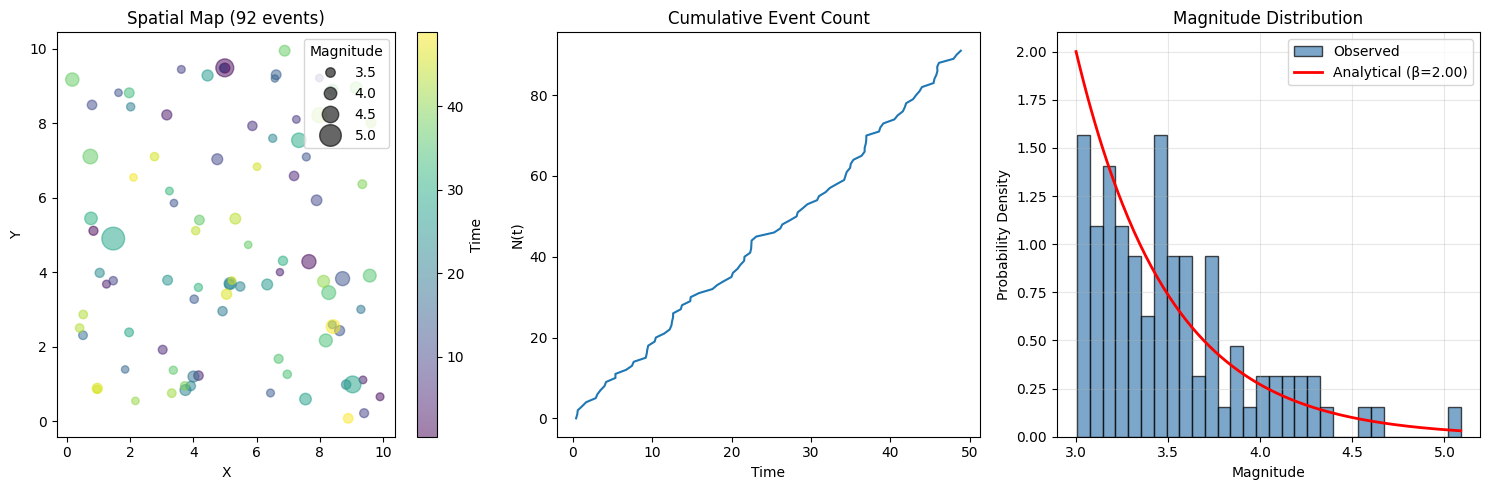

In [15]:

# Create figure with 3 subplots
fig = plt.figure(figsize=(15, 5))

# Subplot 1: Spatial Map
ax1 = plt.subplot(1, 3, 1)
scatter = ax1.scatter(
    x_coords,
    y_coords,
    s=3**np.array(mags),
    alpha=0.5,
    c=times
    )
plt.colorbar(scatter, label='Time', ax=ax1)
ax1.set_title(f'Spatial Map ({len(catalog)} events)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Add legend for scatter sizes (magnitudes) using PathCollection.legend_elements()
# Define inverse transformation: size -> magnitude (size = 3**magnitude, so magnitude = log(size)/log(3))
def inv_trans(s):
    """Transform marker size back to magnitude"""
    return np.log(s) / np.log(3)

# Use legend_elements() with prop="sizes" to create legend based on marker sizes
# func parameter transforms sizes back to magnitudes for the labels
handles, labels = scatter.legend_elements(prop="sizes", num=5, func=inv_trans, fmt="{x:.1f}", alpha=0.6)
ax1.legend(handles, labels, loc='upper right', title='Magnitude')

# Subplot 2: Cumulative Event Count
ax2 = plt.subplot(1, 3, 2)
ax2.plot(times, range(len(times)))
ax2.set_title('Cumulative Event Count')
ax2.set_xlabel('Time')
ax2.set_ylabel('N(t)')

# Subplot 3: Magnitude Distribution
ax3 = plt.subplot(1, 3, 3)
# Histogram of magnitudes
n_bins = 30
counts, bins, patches = ax3.hist(mags, bins=n_bins, density=True, alpha=0.7, label='Observed', color='steelblue', edgecolor='black')

# Analytical PDF: f(m) = beta * exp(-beta*(m-m0)) for m >= m0
m0 = params['m0']
beta = params['beta']
m_analytical = np.linspace(m0, max(mags), 200)
pdf_analytical = beta * np.exp(-beta * (m_analytical - m0))
ax3.plot(m_analytical, pdf_analytical, 'r-', linewidth=2, label=f'Analytical (β={beta:.2f})')

ax3.set_xlabel('Magnitude')
ax3.set_ylabel('Probability Density')
ax3.set_title('Magnitude Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
